# 3D *Staphylococcus aureus* septa and z-stack acquisition

This notebook demonstrates the 3D staph membrane model, arbitrary septum orientations, 3D volume viewing, z-stack acquisition, and timelapse imaging with anisotropic voxels.


In [1]:
from pathlib import Path

import numpy as np
import stackview
from matplotlib import pyplot as plt
from tifffile import imwrite

from maicroscopy_sandbox.maicroscopy_sandbox import mAIcroscopySandbox
from maicroscopy_sandbox.samples.staph import StaphMembrane

np.random.seed(12)
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

def show_panel(images, titles, cmap="magma"):
    fig, axes = plt.subplots(
        1, len(images), figsize=(4 * len(images), 4), constrained_layout=True
    )
    if len(images) == 1:
        axes = [axes]
    for ax, image, title in zip(axes, images, titles):
        ax.imshow(image, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
    return fig


## Arbitrary septum orientations

The staph sample now renders a 3D spheroidal cell. Septa are generated as 3D closing rings that become filled disks, then the normal 2D mask is the central z slice of that volume. The tilt distribution can be selected with strings, `(low, high)` tuples, or callables.


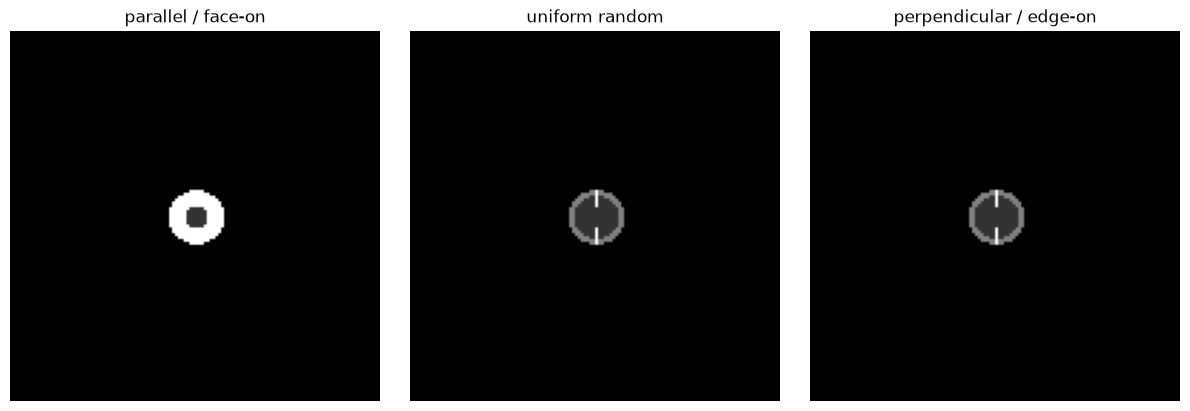

In [2]:
samples = []
titles = []
configs = [
    ("parallel / face-on", "parallel", (0, 0)),
    ("uniform random", "uniform", "uniform"),
    ("perpendicular / edge-on", "perpendicular", (0, 0)),
]

for title, tilt_distribution, rotation_distribution in configs:
    sample = StaphMembrane(
        sample_size=[128, 128],
        n_objects=1,
        pixel_size=64,
        z_size=32,
        voxel_size=(64, 100),
        progression_rate=0,
        cell_size_std=0,
        axis_ratio=1.2,
        septum_tilt_distribution=tilt_distribution,
        septum_rotation_distribution=rotation_distribution,
    )
    cell = next(iter(sample.cells.values()))
    cell.center_row = 64
    cell.center_col = 64
    cell.progression = cell.p1 + int(cell.p2 * 0.6)
    cell.orientation = 0
    samples.append(sample.generate_mask())
    titles.append(title)

show_panel(samples, titles, cmap="gray");


## Inspect the 3D cell volume

A full sample volume can be generated directly. The static orthogonal views give a quick overview, and the following cell opens the same `(z, y, x)` data with `stackview`.


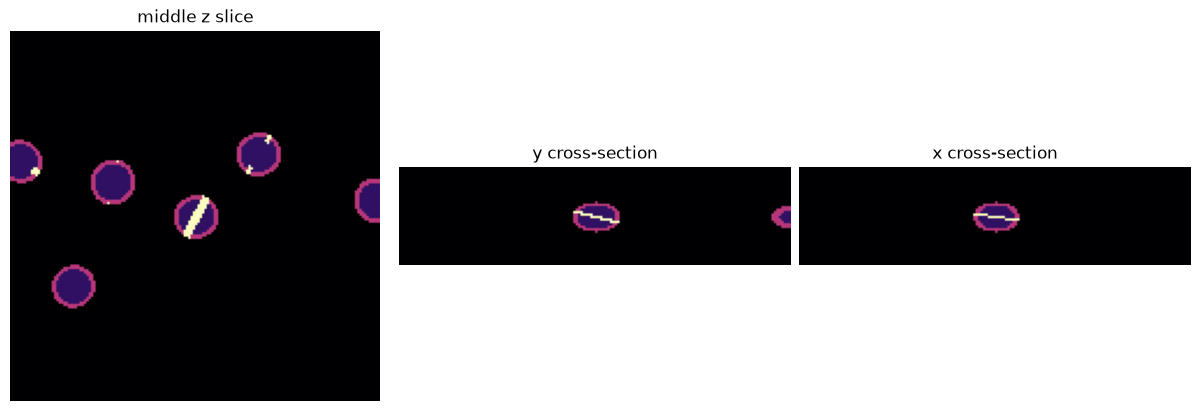

In [3]:
sample_3d = StaphMembrane(
    sample_size=[160, 160],
    n_objects=6,
    pixel_size=64,
    z_size=40,
    voxel_size=(64, 100),
    progression_rate=0,
    septum_tilt_distribution="uniform",
    septum_rotation_distribution="uniform",
    cyto_fluor=0.35,
)
volume = sample_3d.generate_volume()
z_mid, y_mid, x_mid = np.array(volume.shape) // 2

show_panel(
    [volume[z_mid], volume[:, y_mid, :], volume[:, :, x_mid]],
    ["middle z slice", "y cross-section", "x cross-section"],
    cmap="magma",
);


In [4]:
stackview.slice(volume, colormap="magma", continuous_update=True)


## 3D microscope stack acquisition

The microscope accepts `voxel_size=(xy_nm, z_nm)`. With 64 nm xy sampling and 100 nm z steps, axial signal is binned before per-plane fluorescence noise is generated, approximating lower axial resolution.


In [5]:
microscope = mAIcroscopySandbox(
    stage_size=[160, 160],
    fov_size=[128, 128],
    pixel_size=64,
    voxel_size=(64, 100),
    axial_binning_sigma=1.2,
    laser_intensity=800,
    gaussian_sigma=1.0,
    output_dtype="float32",
    random_seed=21,
)
microscope.set_readout_noise(30)
microscope.set_ADC_offset(100)
microscope.load_sample(sample_3d, acquire=False)

frame = microscope.acquire_image()
stack = microscope.acquire_stack()
print(frame.shape, stack.shape, stack.dtype)


Loading sample of size: [160, 160]
Resetting stage position to center position
(128, 128) (40, 128, 128) float32


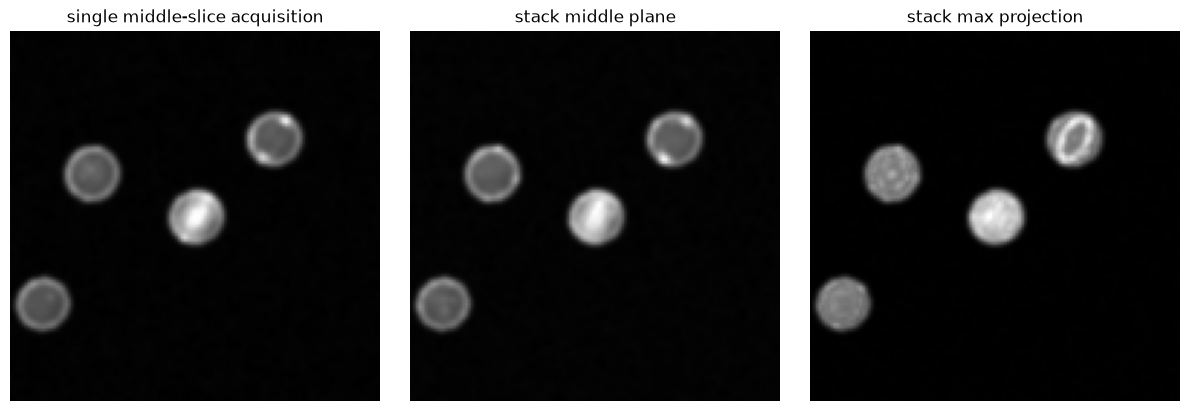

In [6]:
z_mid = stack.shape[0] // 2
max_projection = stack.max(axis=0)

show_panel(
    [frame, stack[z_mid], max_projection],
    ["single middle-slice acquisition", "stack middle plane", "stack max projection"],
    cmap="gray",
);


In [7]:
stackview.slice(stack, colormap="gray", continuous_update=True)


In [8]:
imwrite(output_dir / "staph_3d_stack.tif", stack, imagej=True)


## 2D timelapse acquisition

This timelapse acquires repeated middle-plane frames from an evolving 3D sample. Cell-cycle progression advances between frames, septa continue closing, and bleaching is updated by the microscope after each exposure.


In [9]:
timelapse_sample = StaphMembrane(
    sample_size=[160, 160],
    n_objects=8,
    pixel_size=64,
    z_size=40,
    voxel_size=(64, 100),
    progression_rate=3,
    septum_tilt_distribution="uniform",
    septum_rotation_distribution="uniform",
    cyto_fluor=0.35,
)

timelapse_scope = mAIcroscopySandbox(
    stage_size=[160, 160],
    fov_size=[128, 128],
    pixel_size=64,
    voxel_size=(64, 100),
    axial_binning_sigma=1.2,
    laser_intensity=700,
    gaussian_sigma=1.0,
    output_dtype="float32",
    random_seed=31,
)
timelapse_scope.set_readout_noise(30)
timelapse_scope.set_ADC_offset(100)
timelapse_scope.load_sample(timelapse_sample, acquire=False)

n_timepoints = 24
timelapse = np.stack([timelapse_scope.acquire_image() for _ in range(n_timepoints)])
timelapse.shape


Loading sample of size: [160, 160]
Resetting stage position to center position


(24, 128, 128)

In [10]:
stackview.slice(timelapse, colormap="gray", continuous_update=True)


In [11]:
imwrite(output_dir / "staph_timelapse_2d.tif", timelapse, imagej=True)


## 3D timelapse acquisition

This example acquires a full z stack at each timepoint, producing a `(time, z, y, x)` array. It is saved with `imwrite` as an ImageJ hyperstack with `TZYX` axes.


In [15]:
timelapse_3d_sample = StaphMembrane(
    sample_size=[500, 500],
    n_objects=10,
    pixel_size=64,
    z_size=24,
    voxel_size=(64, 100),
    progression_rate=4,
    septum_tilt_distribution="uniform",
    septum_rotation_distribution="uniform",
    cyto_fluor=0.35,
)

timelapse_3d_scope = mAIcroscopySandbox(
    stage_size=[500, 500],
    fov_size=[256, 256],
    pixel_size=64,
    voxel_size=(64, 100),
    axial_binning_sigma=1.2,
    laser_intensity=650,
    gaussian_sigma=1.0,
    output_dtype="float32",
    random_seed=41,
)
timelapse_3d_scope.set_readout_noise(30)
timelapse_3d_scope.set_ADC_offset(100)
timelapse_3d_scope.load_sample(timelapse_3d_sample, acquire=False)

n_3d_timepoints = 8
timelapse_3d = np.stack(
    [timelapse_3d_scope.acquire_stack() for _ in range(n_3d_timepoints)]
)
timelapse_3d.shape


Loading sample of size: [500, 500]
Resetting stage position to center position


(8, 24, 256, 256)

In [13]:
stackview.slice(timelapse_3d, colormap="gray", continuous_update=True)


In [16]:
imwrite(
    output_dir / "staph_timelapse_3d.tif",
    timelapse_3d,
    imagej=True,
    metadata={"axes": "TZYX", "spacing": 0.1, "unit": "um", "finterval": 1.0},
)
